In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# get data 80

In [3]:
import os
import shutil
from att_tools import update_risk_by_ref
from data_vis.yolo_sta import yolo_sta
from yolo_tools import copy_dir, copy_all, copy_split, data_tf_pipline_new, copy_ref_csv
from yolo_mask_crop import myolo_crop

In [4]:
base_dir = r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030'
image_dir = os.path.join(base_dir, 'images')
label_ana_dir = os.path.join(base_dir, 'labels_analysis')
attribute_file = os.path.join(base_dir, 'attribute.yaml')
class_file = os.path.join(base_dir, 'class.txt')
class_c6_path = r'/localnvme/data/billboard/class_c6.txt'
class_c5_path = r'/localnvme/data/billboard/class_c5.txt'
att_l3_path = r'/localnvme/data/billboard/attribute.yaml'
att_l2_path = r'/localnvme/data/billboard/attribute_l2.yaml'
input_dir = base_dir
input_train_test_path = os.path.join(input_dir, 'train_test.txt')
input_val_test_path = os.path.join(input_dir, 'val_test.txt')
input_train_80p_path = os.path.join(input_dir, 'train_80p_ref.txt')
input_val_80p_path = os.path.join(input_dir, 'val_80p_ref.txt')
input_all_path = os.path.join(input_dir, 'all.txt')
input_all_test_path = os.path.join(input_dir, 'all_test.txt')
label_v21_dir = os.path.join(base_dir, 'labels_v21')
label_v20_dir = os.path.join(base_dir, 'labels_v20')
label_v21_sta_dir = os.path.join(label_ana_dir, 'labels_v21_sta')
label_v20_sta_dir = os.path.join(label_ana_dir, 'labels_v20_sta')
datav21_dir =  r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1117_v21'
datav21_dir_image = os.path.join(datav21_dir, 'images')
datav21_dir_label = os.path.join(datav21_dir, 'labels')
datav21_dir_label_crop = os.path.join(datav21_dir, 'labels_analysis', 'labels_crop')
syn_data_dir = r'/scrinvme/huilin/isds/check_data/synthetic_data_add4_v1'
syn_data_dir_image = os.path.join(syn_data_dir, 'images')
syn_data_dir_label = os.path.join(syn_data_dir, 'labels')

In [5]:
copy_dir(syn_data_dir_image, image_dir)

copy_dir: 100%|██████████| 28/28 [00:00<00:00, 39449.28it/s]

copy error, cam3_20251111113827499_synthetic.jpg exists
copy error, cam3_20251111113827499_synthetic_empty.jpg exists
copy error, cam3_20251111113828500_synthetic.jpg exists
copy error, cam3_20251111113828500_synthetic_empty.jpg exists
copy error, cam4_20251111111331400_synthetic.jpg exists
copy error, cam4_20251111111331400_synthetic_empty.jpg exists
copy error, cam6_20251113112516500_synthetic.jpg exists
copy error, cam6_20251113112516500_synthetic_empty.jpg exists
copy error, DA4930148_20250917141401999_synthetic.jpg exists
copy error, DA4930148_20250917141401999_synthetic_empty.jpg exists
copy error, DA5148680_20251008130911899_synthetic.jpg exists
copy error, DA5148680_20251008130911899_synthetic_empty.jpg exists
copy error, DA5148683_20250930165457100_synthetic.jpg exists
copy error, DA5148683_20250930165457100_synthetic_empty.jpg exists
copy error, DA5148683_20251008130642800_synthetic.jpg exists
copy error, DA5148683_20251008130642800_synthetic_empty.jpg exists
copy error, DA51

In [6]:
os.makedirs(label_v21_dir, exist_ok=True)
copy_dir(label_v20_dir, label_v21_dir)
copy_dir(syn_data_dir_label, label_v21_dir)

copy_dir: 100%|██████████| 28/28 [00:00<00:00, 1097.85it/s]


label read: 100%|██████████| 8061/8061 [00:58<00:00, 136.86it/s]


get 8061 labels, merging...


/localnvme/project/dataset_tools/data_vis/yolo_sta.py:303: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfs = pd.concat(dfs)


merging finish, get 62912 labels!
csv save to /localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030/labels_analysis/labels_v20_sta/sta_attribute.csv
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
总box数: 62912; 有缺陷的box数: 4571; 没有缺陷的box数: 58341
总image数: 7955; 有缺陷的image数: 3070; 没有缺陷的image数: 4885
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
category        wall display  projecting frame  projecting display  \
deformation                9                 7                 161   
broken                   212                 1                  97   
abandonment              938                29                 174   
corrosion                131              1129                1337   
attribute sum           1249              1146                1680   
with attribute          1249              1146                1680   

category        hanging frame  hanging display  o

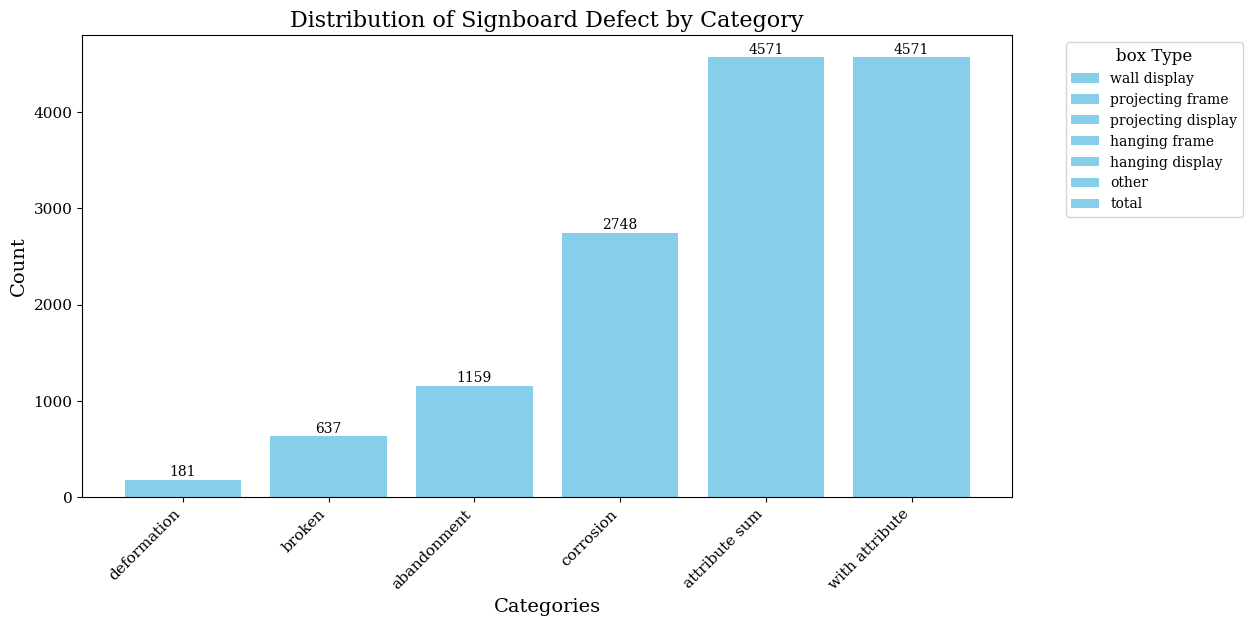

In [7]:
yolo_sta(
    gt_dir=label_v20_dir,
    result_dir=label_v20_sta_dir,
    class_path=class_file,
    attribute_path=attribute_file,
    seg=True,
)

label read: 100%|██████████| 8089/8089 [01:05<00:00, 123.29it/s]


get 8089 labels, merging...


/localnvme/project/dataset_tools/data_vis/yolo_sta.py:303: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfs = pd.concat(dfs)


merging finish, get 63072 labels!
csv save to /localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030/labels_analysis/labels_v21_sta/sta_attribute.csv
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
总box数: 63072; 有缺陷的box数: 4611; 没有缺陷的box数: 58461
总image数: 7983; 有缺陷的image数: 3098; 没有缺陷的image数: 4885
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
category        wall display  projecting frame  projecting display  \
deformation                9                 7                 163   
broken                   227                 1                 109   
abandonment              941                29                 175   
corrosion                131              1129                1337   
attribute sum           1267              1146                1693   
with attribute          1267              1146                1693   

category        hanging frame  hanging display  o

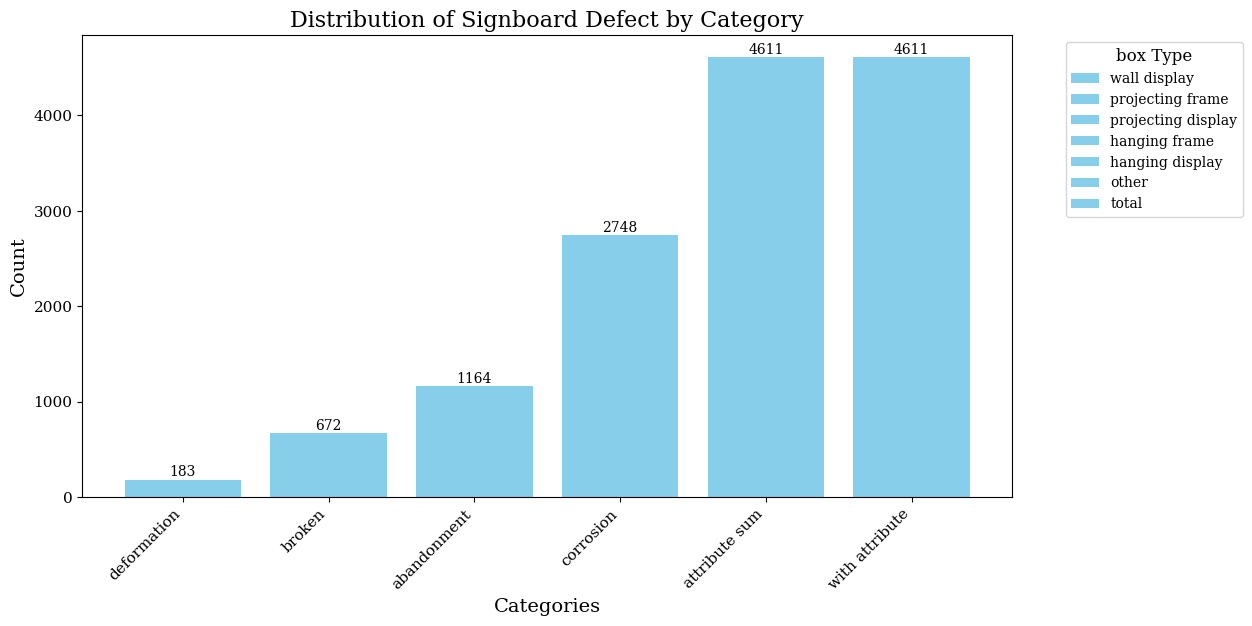

In [8]:
yolo_sta(
    gt_dir=label_v21_dir,
    result_dir=label_v21_sta_dir,
    class_path=class_file,
    attribute_path=attribute_file,
    seg=True,
)

In [9]:
# get data18

In [10]:
copy_all(
    label_v21_dir,
    datav21_dir_label,
    image_dir,
    datav21_dir_image,
)

copy_all: 100%|██████████| 8089/8089 [00:26<00:00, 305.30it/s]


In [11]:
output_dir = datav21_dir
output_train_test_path = os.path.join(output_dir, 'train_test.txt')
output_val_test_path = os.path.join(output_dir, 'val_test.txt')
output_val_test_broken_path = os.path.join(output_dir, 'val_test_broken.txt')
output_train_80p_path = os.path.join(output_dir, 'train_80p_ref.txt')
output_val_80p_path = os.path.join(output_dir, 'val_80p_ref.txt')
output_all_path = os.path.join(output_dir, 'all.txt')
output_all_test_path = os.path.join(output_dir, 'all_test.txt')

copy_split(input_train_test_path, output_train_test_path)
copy_split(input_val_test_path, output_val_test_path)
copy_split(input_train_80p_path, output_train_80p_path)
copy_split(input_val_80p_path, output_val_80p_path)
copy_split(input_all_path, output_all_path)
copy_split(input_all_test_path, output_all_test_path)

shutil.copy(class_c6_path, os.path.join(output_dir, 'class.txt'))
shutil.copy(att_l3_path, os.path.join(output_dir, 'attribute.yaml'))

copy train_test.txt, 7872 records
copy val_test.txt, 80 records
copy train_80p_ref.txt, 7606 records
copy val_80p_ref.txt, 266 records
copy all.txt, 7872 records
copy all_test.txt, 7952 records


'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1117_v21/attribute.yaml'

In [13]:
data_tf_pipline_new(datav21_dir, copy_list=['mseg_c5_l2'])

risk to l2: 100%|██████████| 8089/8089 [00:26<00:00, 310.48it/s]


In [14]:
output_dir = datav21_dir.replace('mseg_c6', 'mseg_c5_l2')
output_train_test_path = os.path.join(output_dir, 'train_test.txt')
output_val_test_path = os.path.join(output_dir, 'val_test.txt')
output_train_80p_path = os.path.join(output_dir, 'train_80p_ref.txt')
output_val_80p_path = os.path.join(output_dir, 'val_80p_ref.txt')
output_all_path = os.path.join(output_dir, 'all.txt')
output_all_test_path = os.path.join(output_dir, 'all_test.txt')

copy_split(input_train_test_path, output_train_test_path, abs_path=True)
copy_split(input_val_test_path, output_val_test_path, abs_path=True)
copy_split(input_train_80p_path, output_train_80p_path, abs_path=True)
copy_split(input_val_80p_path, output_val_80p_path, abs_path=True)
copy_split(input_all_path, output_all_path, abs_path=True)
copy_split(input_all_test_path, output_all_test_path, abs_path=True)

copy train_test.txt, 7872 records
copy val_test.txt, 80 records
copy train_80p_ref.txt, 7606 records
copy val_80p_ref.txt, 266 records
copy all.txt, 7872 records
copy all_test.txt, 7952 records


In [15]:
myolo_crop(
    datav21_dir_image,
    datav21_dir_label,
    datav21_dir_label_crop,
    class_c6_path,
    attribute_file=att_l3_path,
    seg=True,
    annotation=False,
    save_method='attribute',
    only_defect=True,
    with_boundary=False,
    crop_method='with_background_box_shape'
)

100%|██████████| 63071/63071 [00:00<00:00, 104637.32it/s]


In [16]:
# get data80

In [17]:
data80_dir = r'/localnvme/data/billboard/all_data/mseg_c5_l2/data80_v21'
class_c5_path = r'/localnvme/data/billboard/class_c5.txt'
att_l2_path = r'/localnvme/data/billboard/attribute_l2.yaml'

data7961_dir_mseg_c5_l2 = datav21_dir.replace('mseg_c6', 'mseg_c5_l2')
input_image_dir = os.path.join(data7961_dir_mseg_c5_l2, 'images')
input_label_dir = os.path.join(data7961_dir_mseg_c5_l2, 'labels')
# input_val_test_path = os.path.join(data7961_dir_mseg_c5_l2, 'val_test_broken.txt')
input_val_test_path = r'/localnvme/data/billboard/all_data/mseg_c5_l2/data7961_mseg_c5_l2_1117_v19_single_risk/b/val_test_broken_syn_v1.txt'

data80_image_dir = os.path.join(data80_dir, 'images')
data80_label_dir = os.path.join(data80_dir, 'labels')
data80_label_analysis_dir = os.path.join(data80_dir, 'labels_analysis')
data80_label_crop_dir = os.path.join(data80_dir, 'labels_crop')
data80_class_path = os.path.join(data80_dir, 'class.txt')
data80_att_path = os.path.join(data80_dir, 'attribute.yaml')

In [18]:
copy_ref_csv(input_image_dir, data80_image_dir, input_val_test_path)

100%|██████████| 88/88 [00:00<00:00, 214.34it/s]


In [19]:
copy_ref_csv(input_label_dir, data80_label_dir, input_val_test_path)

100%|██████████| 88/88 [00:00<00:00, 4582.57it/s]


In [20]:
shutil.copy(class_c5_path, data80_class_path)
shutil.copy(att_l2_path, data80_att_path)

'/localnvme/data/billboard/all_data/mseg_c5_l2/data80_v21/attribute.yaml'

In [21]:
myolo_crop(
    data80_image_dir,
    data80_label_dir,
    data80_label_crop_dir,
    class_c5_path,
    attribute_file=att_l2_path,
    seg=True,
    annotation=False,
    save_method='attribute',
    only_defect=True,
    with_boundary=False,
    crop_method='with_background_box_shape'
)

100%|██████████| 812/812 [00:00<00:00, 207986.25it/s]
